## Veridian Flow Pilates $ Barre, Predictive Pricing Model

Building a regression model to predict the optimal drop-in-rate for Weekend Pop-up Workshops based on session features.

### 1. Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'. format)

### 2. Generate & Load Data

In [3]:
df = pd.read_csv('veridian_flow_workshops.csv')
print(df.shape)
df.head(10)

(600, 6)


,session_duration,instructor_seniority,class_type,timing,max_capacity,drop_in_rate
0,105,14.90,Hot Yoga,Off-Peak,21,74.62
1,120,2.00,Barre,Peak,16,63.60
2,90,8.80,Hot Yoga,Peak,22,75.03
3,120,14.60,Hot Yoga,Off-Peak,10,83.04
4,120,8.30,Meditation,Off-Peak,9,71.08
5,75,9.80,Meditation,Peak,9,67.42
6,90,10.70,Meditation,Peak,10,71.31
7,90,7.40,Barre,Off-Peak,21,51.33
8,90,9.80,Reformer Pilates,Off-Peak,17,64.24
9,120,9.20,Hot Yoga,Peak,9,75.83


### 3. Exploratory Data Analysis (EDA)

In [4]:
df.describe()

,session_duration,instructor_seniority,max_capacity,drop_in_rate
count,600.00,600.00,600.00,600.00
mean,90.28,7.90,15.90,66.69
std,21.55,4.07,4.91,11.46
min,60.00,1.10,8.00,35.21
25%,75.00,4.30,11.00,58.92
50%,90.00,7.90,16.00,66.33
75%,105.00,11.40,20.00,75.06
max,120.00,15.00,24.00,101.21


C:\Users\binia\AppData\Local\Temp\ipykernel_2668\693163433.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class_type', y='drop_in_rate', palette='Set2', ax=axes[1])


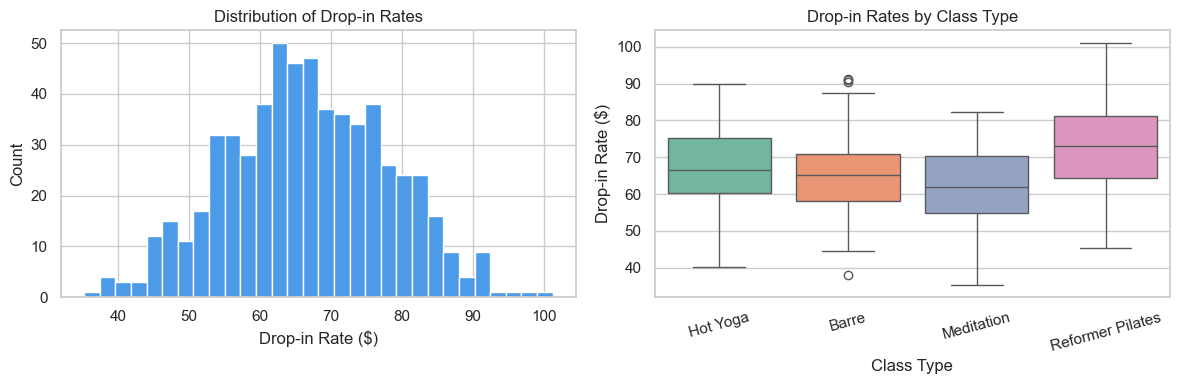

In [5]:
# Drop-in rate distribution
fig , axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['drop_in_rate'], bins=30, color='#4C9BE8', edgecolor='white')
axes[0].set_title('Distribution of Drop-in Rates')
axes[0].set_xlabel('Drop-in Rate ($)')
axes[0].set_ylabel('Count')

sns.boxplot(data=df, x='class_type', y='drop_in_rate', palette='Set2', ax=axes[1])
axes[1].set_title('Drop-in Rates by Class Type')
axes[1].set_xlabel('Class Type')
axes[1].set_ylabel('Drop-in Rate ($)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

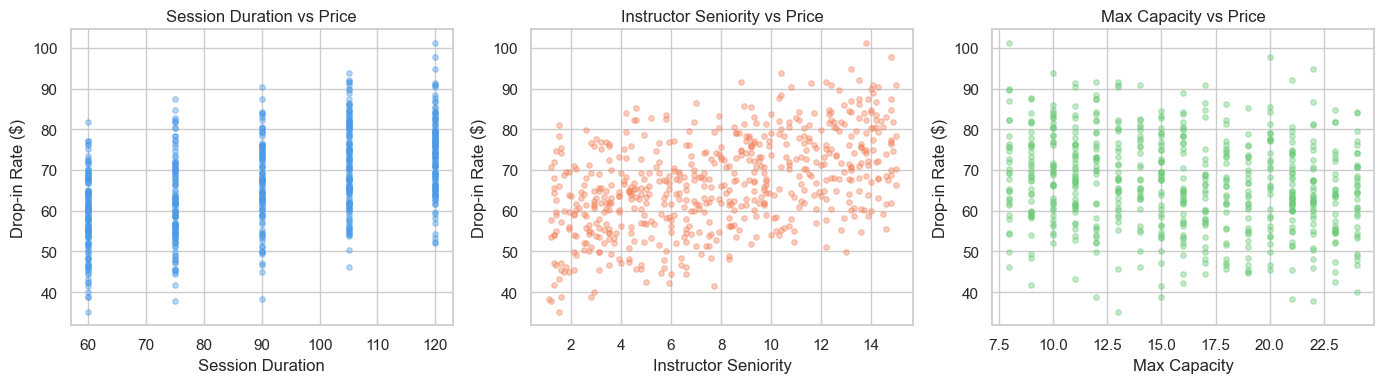

In [6]:
# Scatter plots, numeric features vs price
fig, axes = plt.subplots(1,3, figsize=(14, 4))
num_features = ['session_duration', 'instructor_seniority', 'max_capacity']
colors = ['#4C9BE8','#F4845F', '#6BCB77']

for ax, feat, col in zip(axes, num_features, colors):
    ax.scatter(df[feat], df['drop_in_rate'], alpha=0.4, color=col, s=15)
    ax.set_xlabel(feat.replace('_', ' ').title())
    ax.set_ylabel('Drop-in Rate ($)')
    ax.set_title(f'{feat.replace("_", " ").title()} vs Price')


plt.tight_layout()
plt.show()


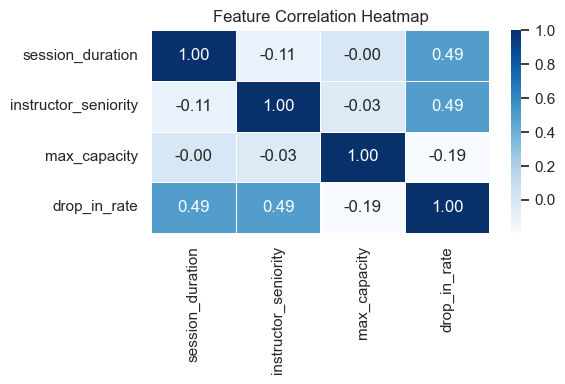

In [7]:
#Now lets do correlation heatmap 
plt.figure(figsize=(6,4))
corr = df[['session_duration', 'instructor_seniority', 'max_capacity', 'drop_in_rate']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### 4. Feature Enigneering

In [8]:
df_model = df.copy()

#Encode Categoricals
df_model = pd.get_dummies(df_model, columns=['class_type', 'timing'], drop_first=False)
df_model = df_model.drop(columns=['class_type_Barre', 'timing_Off-Peak'])

X = df_model.drop('drop_in_rate', axis = 1)
y = df_model['drop_in_rate']

num_cols = ['session_duration', 'instructor_seniority', 'max_capacity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[num_cols] =scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Scaler means: {scaler.mean_}')
print(f'Scaler scale: {scaler.scale_}')

Train: (480, 7) | Test: (120, 7)
Scaler means: [90.5         7.93895833 16.05416667]
Scaler scale: [21.53630655  4.10582956  4.92878274]


### 5. Modeling, Linear Regression vs Decision Tree

In [9]:
models = {
    'LinearRegression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42)
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    results[name] = {
        'MAE': round(mean_absolute_error(y_test, preds), 3),
        'R2': round(r2_score(y_test, preds), 3),
        'preds': preds
    }

pd.DataFrame(results).T[['MAE', 'R2']]

,MAE,R2
LinearRegression,3.42,0.86
Decision Tree,5.24,0.69


### 6. Evaluation, Actual vs Predicted

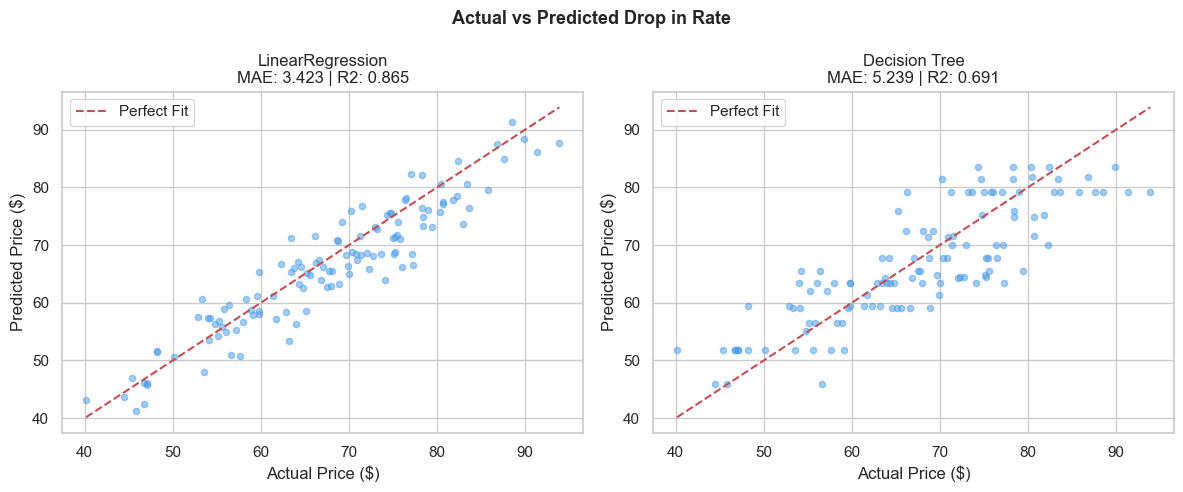

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))

for ax, (name, res) in zip(axes, results.items()):
    ax.scatter(y_test, res['preds'], alpha=0.5, color='#4C9BE8', s=20)
    lims = [min(y_test.min(), res['preds'].min()), max(y_test.max(), res['preds'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.set_title(f'{name}\nMAE: {res["MAE"]} | R2: {res["R2"]}')
    ax.legend()

plt.suptitle('Actual vs Predicted Drop in Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7. Feature Importance (Decision Tree)

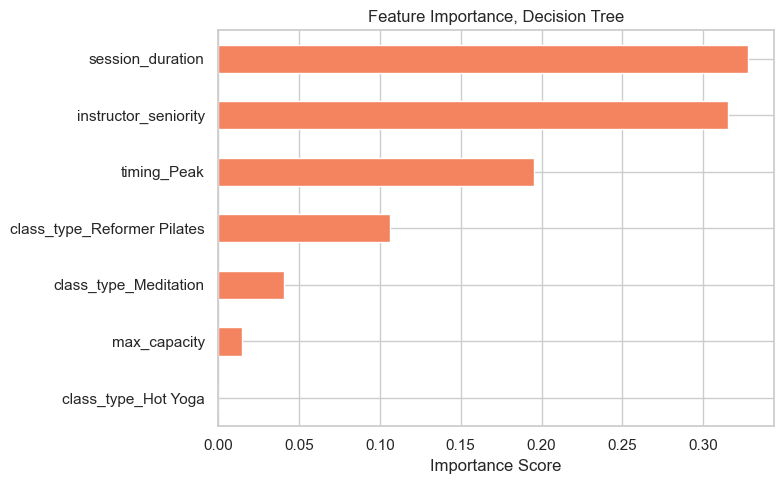

In [13]:
dt_model = models['Decision Tree']
importance = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8,5))
importance.plot(kind='barh', color='#F4845F', edgecolor='white')
plt.title('Feature Importance, Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


### 8. Deployment Simulation, Price Prediction Funciton

In [21]:
def predict_price(session_duration, instructor_seniority, class_type, timing, max_capacity):
    input_dict = {
        'session_duration': session_duration,
        'instructor_seniority': instructor_seniority,
        'max_capacity': max_capacity,
        'class_type_Hot Yoga': 1 if class_type == 'Hot yoga' else 0,
        'class_type_Meditation': 1 if class_type == 'Meditation' else 0,
        'class_type_Reformer Pilates': 1 if class_type == 'Reformer Pilates' else 0,
        'timing_Peak': 1 if timing == 'Peak' else 0,
    }

    input_df = pd.DataFrame([input_dict])
    input_df = input_df.reindex(columns=X_train.columns, fill_value=0)
    input_df[num_cols] = scaler.transform(input_df[num_cols])

    lr_price = models['LinearRegression']. predict(input_df)[0]
    dt_price = models['Decision Tree'].predict(input_df)[0]

    print(f"Workshop: {session_duration}-min {class_type} | {timing} | Instructor: {instructor_seniority} yrs | Capacity: {max_capacity}")
    print(f"Linear Regression prediction : ${lr_price:.2f}")
    print(f"Decision Tree prediction     : ${dt_price:.2f}")
    print(f"Recommended price            : ${(lr_price + dt_price)/2:.2f} (average of both models)")

predict_price(
    session_duration=105,
    instructor_seniority=12,
    class_type= 'Reformer Pilates',
    timing='Peak',
    max_capacity= 10
)


Workshop: 105-min Reformer Pilates | Peak | Instructor: 12 yrs | Capacity: 10
Linear Regression prediction : $90.13
Decision Tree prediction     : $79.13
Recommended price            : $84.63 (average of both models)


## Summary

This notebook builds a predictive pricing model for Veridian Flow's Weekend Pop-up Workshops using 600 synthetic records

**Key Findings:**
- **Session Duration** and **instructor seniority** are the strongest price drivers, accounting for 60%+ of predictive weight
- **Reformer Pilates** commands the highest rates; **Meidtation** the lowest
- **Peak timing** adds approximately $10 to any session; larger capacity slightly reduces price

**Model Performances:**

- Linear Regression: MAE $3.42 | Rsquared 0.86
- Decision Tree: MAE $5.24 | R squared 0.69
- Both exceed the Rsquared >- 0.70 threshold, Linear Regression is the stronger model

**Recommended price** for a 105 min Advanved Reformer class with a 12 year instructor at Peak timing, capacity 10: **%84.63**